In [1]:
import numpy as np
import sklearn
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import imageio.v3 as iio
import os
from PIL import Image
import imagehash
import seaborn as sns


# Data loading and Processing

In [2]:
Image_size = 96
Batch = 32
Random_seed = 42

train_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="training",
    seed=Random_seed,
    image_size=(Image_size, Image_size),
    batch_size=None
)

val_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Training_Bi/",
    validation_split=0.15,
    subset="validation",
        seed=Random_seed,
        image_size=(Image_size, Image_size),
        batch_size=None
)

test_Bi_raw = tf.keras.utils.image_dataset_from_directory(
    "Test/",
    image_size=(Image_size, Image_size),
    batch_size=None,
    shuffle=False
)



Found 39375 files belonging to 2 classes.
Using 33469 files for training.
Found 39375 files belonging to 2 classes.
Using 5906 files for validation.
Found 8617 files belonging to 2 classes.


In [3]:
def focal_loss(gamma, alpha):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        focal_weight = alpha * tf.pow(1 - p_t, gamma)
        return tf.reduce_mean(focal_weight * bce)
    return loss


def augment(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))
    image = tf.image.random_brightness(image, max_delta=0.3)
    image = tf.image.random_contrast(image, lower=0.7, upper=1.4)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.6)
    image = tf.image.random_hue(image, max_delta=0.05)
    
    # Haze - fixed with tf.cond
    haze_intensity = tf.random.uniform((), 0.05, 0.25)
    haze = tf.ones_like(image) * 0.7
    image = tf.cond(
        tf.random.uniform(()) > 0.5,
        lambda: image * (1 - haze_intensity) + haze * haze_intensity,
        lambda: image
    )

    # Blur - fixed with tf.cond
    def apply_blur(img):
        img = tf.expand_dims(img, 0)
        img = tf.nn.avg_pool2d(img, ksize=3, strides=1, padding='SAME')
        return tf.squeeze(img, 0)

    image = tf.cond(
        tf.random.uniform(()) > 0.6,
        lambda: apply_blur(image),
        lambda: image
    )

    image = tf.clip_by_value(image, 0.0, 1.0)
    return image, label

def normalize(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

def compute_class_weights(ds):
    labels = np.array([y.numpy() for _, y in ds])
    counts = np.bincount(labels)
    total = len(labels)
    weights = {i: total / (len(counts) * c) for i, c in enumerate(counts)}
    print(f"Class weights: {weights}")
    return weights

In [4]:
class_weights = compute_class_weights(train_Bi_raw)

train_ds = (
    train_Bi_raw
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
val_ds = (
    val_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)
test_ds = (
    test_Bi_raw
    .map(normalize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(Batch)
    .prefetch(tf.data.AUTOTUNE)
)

Class weights: {0: 0.787542943197327, 1: 1.3694353518821605}


In [8]:

# ── focal loss (keep your original) ─────────────────────────────────────────
def focal_loss(gamma=2.0, alpha=0.25):
    def loss_fn(y_true, y_pred):
        import tensorflow as tf
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        bce = -y_true * tf.math.log(y_pred) - (1 - y_true) * tf.math.log(1 - y_pred)
        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)
        return tf.reduce_mean(alpha * tf.pow(1 - p_t, gamma) * bce)
    return loss_fn

# ── model builder ────────────────────────────────────────────────────────────
def build_model(size='medium', loss_fn=None, learning_rate=1e-4):
    """
    size        : 'tiny' | 'small' | 'medium' (your original) | 'large' | 'xlarge'
    loss_fn     : any compiled Keras loss, or None → defaults to focal_loss
    learning_rate: float
    """
    if loss_fn is None:
        loss_fn = focal_loss(gamma=2.0, alpha=0.25)

    configs = {
        #          filters per block,         dense
        'tiny':   ([4,  4],                   8),
        'small':  ([8,  8,  16],              16),
        'medium': ([8,  8,  16, 16, 32, 32],  16),   # ← your original
        'large':  ([16, 16, 32, 32, 64, 64],  32),
        'xlarge': ([32, 32, 64, 64, 128,128], 64),
    }

    filter_pairs, dense_units = configs[size]
    layers = []

    # Build conv blocks (every 2 filters = one block with pooling + dropout)
    for i in range(0, len(filter_pairs) - 1, 2):
        f = filter_pairs[i]
        layers += [
            keras.layers.Conv2D(f, 3, activation='relu', padding='same'),
            keras.layers.Conv2D(f, 3, activation='relu', padding='same'),
            keras.layers.MaxPooling2D(),
            keras.layers.Dropout(0.2 if f < 64 else 0.3),
        ]
    # Final conv (no pooling — goes into GAP)
    if len(filter_pairs) % 2 != 0:
        layers.append(keras.layers.Conv2D(filter_pairs[-1], 3, activation='relu', padding='same'))
    else:
        layers.append(keras.layers.Conv2D(filter_pairs[-1]*2, 3, activation='relu', padding='same'))

    layers += [
        keras.layers.GlobalAveragePooling2D(),
        keras.layers.Dense(dense_units, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(1, activation='sigmoid'),
    ]

    model = keras.models.Sequential(layers)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate),
        loss=loss_fn,
        metrics=[
            'accuracy',
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision'),
        ]
    )
    return model


def get_callbacks(size):
    return [
        keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=5, restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=2, min_lr=1e-7
        ),
        keras.callbacks.ModelCheckpoint(
            f'best_fire_model_{size}.keras',
            monitor='val_recall', save_best_only=True
        ),
    ]


# ── train multiple sizes ─────────────────────────────────────────────────────
def train_all(train_ds, val_ds, test_ds,
              sizes=('tiny', 'small', 'medium', 'large', 'xlarge'),
              loss_fn=None, epochs=30, threshold=0.35):
    """
    Trains every size, evaluates on test_ds, returns a results dict.
    loss_fn : pass any Keras-compatible loss, or None for focal_loss default.
    """
    results = {}

    for size in sizes:
        print(f"\n{'='*50}")
        print(f"  Training: {size.upper()}")
        print(f"{'='*50}")

        model = build_model(size=size, loss_fn=loss_fn)
        history = model.fit(
            train_ds, epochs=epochs,
            validation_data=val_ds,
            callbacks=get_callbacks(size),
            verbose=1
        )

        loss, acc, recall, precision = model.evaluate(test_ds, verbose=0)
        y_pred_prob = model.predict(test_ds, verbose=0)
        true_labels = np.concatenate([y.numpy() for _, y in test_ds])
        pred_classes = (y_pred_prob > threshold).astype(int).flatten()
        cm = confusion_matrix(true_labels, pred_classes)

        results[size] = {
            'model':   model,
            'history': history,
            'loss':    loss,
            'acc':     acc,
            'recall':  recall,
            'precision': precision,
            'cm':      cm,
            'true_labels': true_labels,
            'pred_classes': pred_classes,
        }
        print(f"  → acc={acc:.4f}  recall={recall:.4f}  precision={precision:.4f}")

    return results


# ── comparative plots ────────────────────────────────────────────────────────
def plot_comparison(results, threshold=0.35):
    sizes  = list(results.keys())
    colors = plt.cm.tab10(np.linspace(0, 0.6, len(sizes)))
    class_names = ['No Fire', 'Fire']

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle('Model Size Comparison', fontsize=16, fontweight='bold', y=0.98)

    # ── 1. Val Loss curves (plateau view) ───────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    for (size, res), c in zip(results.items(), colors):
        val_loss = res['history'].history['val_loss']
        ax1.plot(range(1, len(val_loss)+1), val_loss,
                 '-o', markersize=3, color=c, label=size)
        best = np.argmin(val_loss) + 1
        ax1.axvline(best, color=c, linestyle='--', alpha=0.4, linewidth=1)
    ax1.set_title('Val Loss — Plateau View', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Val Loss')
    ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

    # ── 2. Train Loss curves ─────────────────────────────────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    for (size, res), c in zip(results.items(), colors):
        train_loss = res['history'].history['loss']
        ax2.plot(range(1, len(train_loss)+1), train_loss,
                 '-o', markersize=3, color=c, label=size)
    ax2.set_title('Train Loss', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
    ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

    # ── 3. Val Accuracy curves ───────────────────────────────────────────────
    ax3 = fig.add_subplot(2, 3, 3)
    for (size, res), c in zip(results.items(), colors):
        val_acc = res['history'].history['val_accuracy']
        ax3.plot(range(1, len(val_acc)+1), val_acc,
                 '-o', markersize=3, color=c, label=size)
    ax3.set_title('Val Accuracy', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Accuracy')
    ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

    # ── 4. Bar chart — test metrics ──────────────────────────────────────────
    ax4 = fig.add_subplot(2, 3, 4)
    metrics   = ['acc', 'recall', 'precision']
    bar_labels = ['Accuracy', 'Recall', 'Precision']
    x = np.arange(len(sizes))
    width = 0.25
    for i, (metric, label) in enumerate(zip(metrics, bar_labels)):
        vals = [results[s][metric] for s in sizes]
        bars = ax4.bar(x + i*width, vals, width, label=label, alpha=0.85)
        for bar, v in zip(bars, vals):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=7)
    ax4.set_title('Test Metrics by Model Size', fontweight='bold')
    ax4.set_xticks(x + width); ax4.set_xticklabels(sizes)
    ax4.set_ylabel('Score'); ax4.set_ylim(0, 1.12)
    ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3, axis='y')

    # ── 5. Epochs trained (early stopping) ──────────────────────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    epoch_counts = [len(results[s]['history'].history['loss']) for s in sizes]
    best_epochs  = [np.argmin(results[s]['history'].history['val_loss'])+1 for s in sizes]
    ax5.bar(sizes, epoch_counts, color=colors, alpha=0.6, label='Total epochs trained')
    ax5.bar(sizes, best_epochs,  color=colors, alpha=1.0, label='Best epoch')
    ax5.set_title('Epochs Trained vs Best Epoch', fontweight='bold')
    ax5.set_ylabel('Epochs'); ax5.legend(fontsize=9)
    ax5.grid(True, alpha=0.3, axis='y')
    for i, (tot, best) in enumerate(zip(epoch_counts, best_epochs)):
        ax5.text(i, tot + 0.3, str(tot), ha='center', fontsize=9)
        ax5.text(i, best/2,    str(best), ha='center', fontsize=9, color='white', fontweight='bold')

    # ── 6. Confusion matrices (small multiples) ──────────────────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')
    n = len(sizes)
    cols = min(n, 3)
    rows = (n + cols - 1) // cols
    inner = ax6.get_position()
    cell_w = inner.width  / cols
    cell_h = inner.height / rows

    for idx, size in enumerate(sizes):
        cm = results[size]['cm']
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        row, col = divmod(idx, cols)
        left   = inner.x0 + col * cell_w + cell_w * 0.05
        bottom = inner.y1 - (row+1) * cell_h + cell_h * 0.1
        sub_ax = fig.add_axes([left, bottom, cell_w*0.88, cell_h*0.82])
        annot  = np.array([[f"{v:.0%}" for v in r] for r in cm_norm])
        sns.heatmap(cm_norm, annot=annot, fmt='', cmap='Reds',
                    xticklabels=['NF','F'], yticklabels=['NF','F'],
                    cbar=False, linewidths=0.5, ax=sub_ax, annot_kws={'size': 8})
        sub_ax.set_title(size, fontsize=9, fontweight='bold')
        sub_ax.tick_params(labelsize=7)

    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved → model_comparison.png")

In [ ]:
results = train_all(train_ds, val_ds, test_ds,
                    sizes=('small', 'medium', 'large'))


  Training: SMALL
Epoch 1/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6543 - loss: 0.5834 - precision: 0.9895 - recall: 0.0538 - val_accuracy: 0.6614 - val_loss: 0.4630 - val_precision: 1.0000 - val_recall: 0.0641 - learning_rate: 1.0000e-04
Epoch 2/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.8850 - loss: 0.4137 - precision: 0.9816 - recall: 0.6981 - val_accuracy: 0.9162 - val_loss: 0.3579 - val_precision: 1.0000 - val_recall: 0.7684 - learning_rate: 1.0000e-04
Epoch 3/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9212 - loss: 0.3370 - precision: 0.9517 - recall: 0.8261 - val_accuracy: 0.9282 - val_loss: 0.3255 - val_precision: 1.0000 - val_recall: 0.8016 - learning_rate: 1.0000e-04
Epoch 4/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9235 - loss: 0.2929 - precision: 0.9450 - recall: 0.8394 - val_accuracy: 0.9360 - val_loss: 0.2723 - val_precision: 1.0000 - val_recall: 0.8231 - learning_rate: 1.0000e-04
Epoch 5/30
10

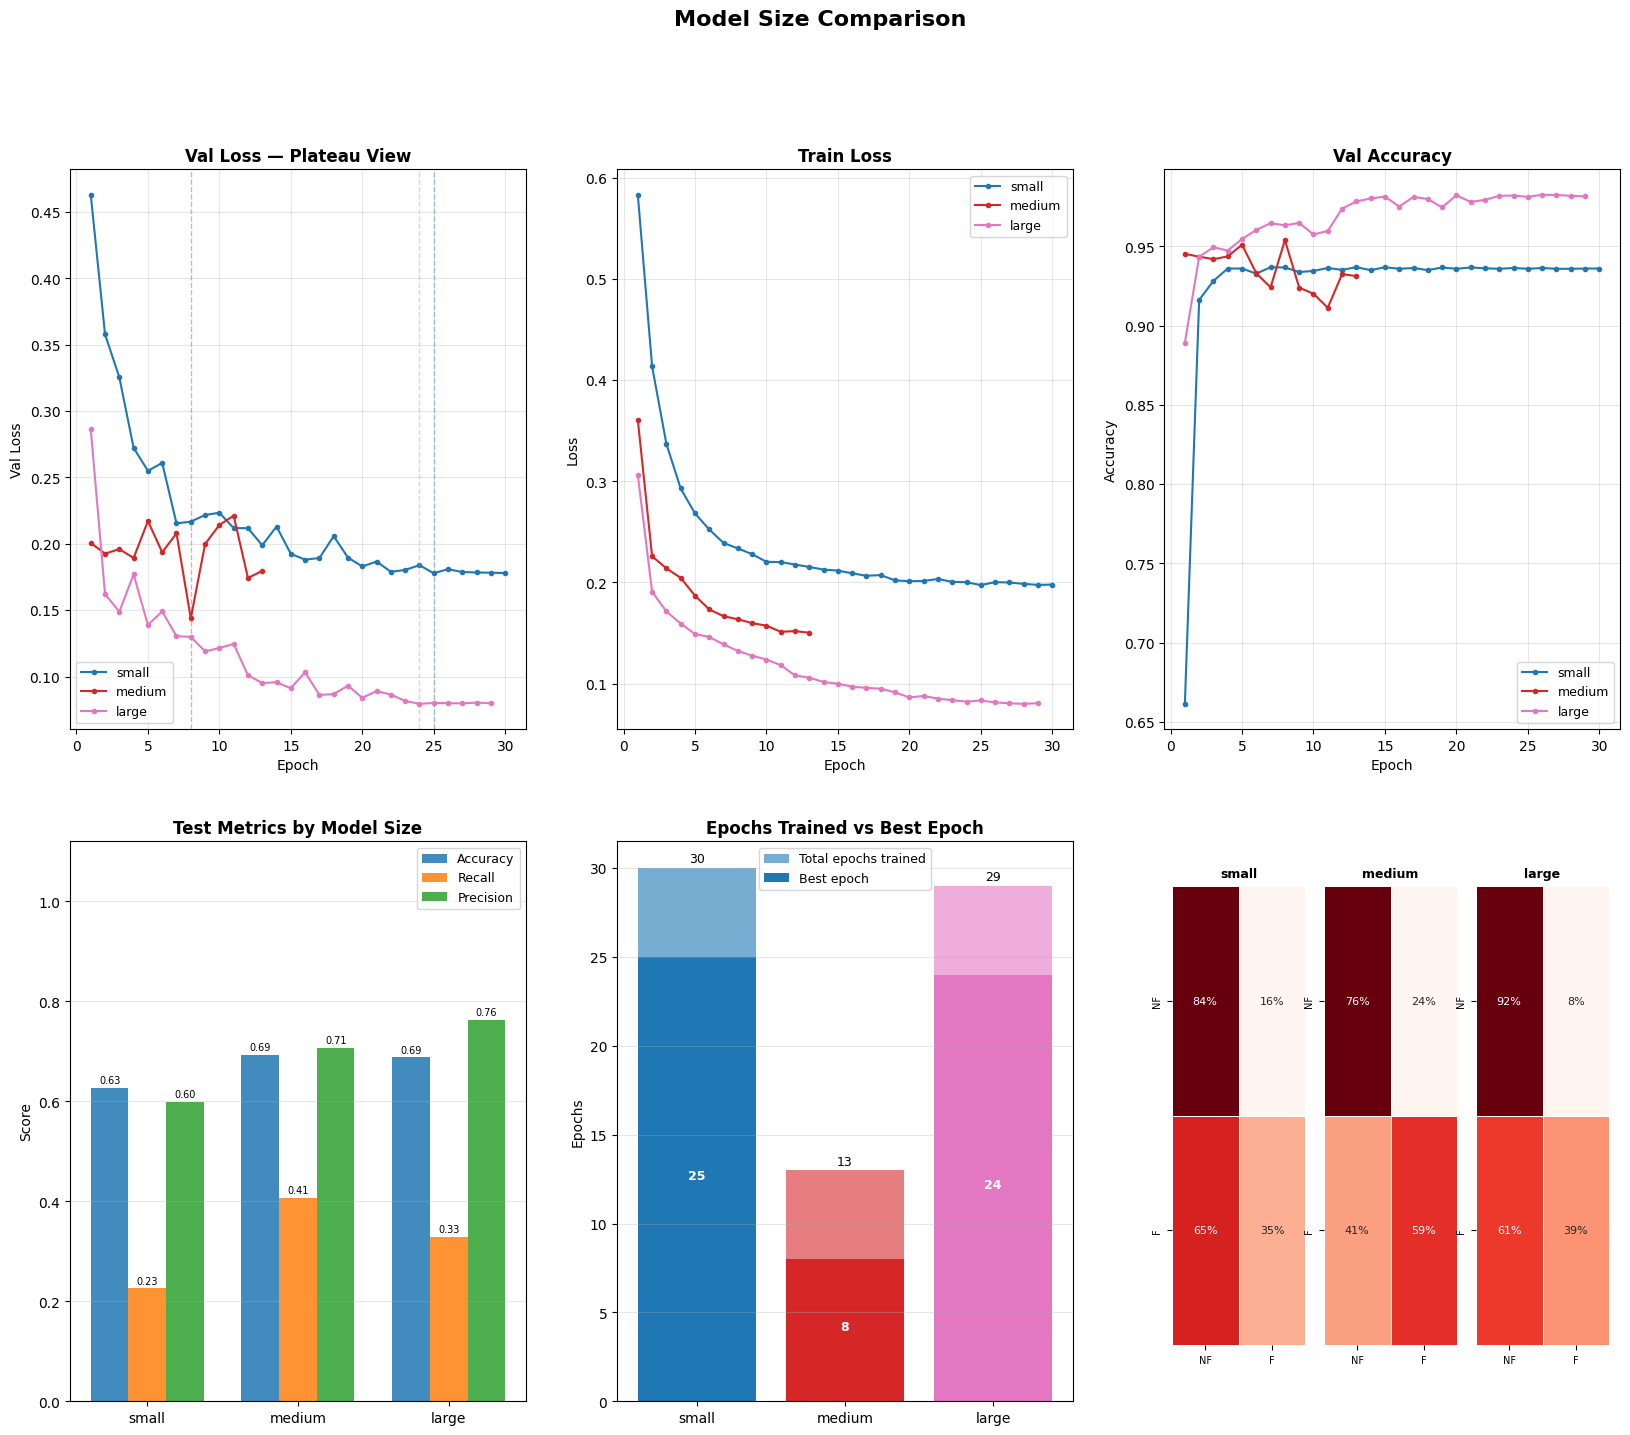

Saved → model_comparison.png


In [11]:
plot_comparison(results)

In [10]:
results = train_all(train_ds, val_ds, test_ds,
                    sizes=('small', 'medium', 'large'))


  Training: SMALL
Epoch 1/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.7053 - loss: 0.0363 - precision: 0.8479 - recall: 0.2349 - val_accuracy: 0.8845 - val_loss: 0.0235 - val_precision: 1.0000 - val_recall: 0.6809 - learning_rate: 1.0000e-04
Epoch 2/30
1046/1046 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8920 - loss: 0.0230 - precision: 0.8983 - recall: 0.7940 - val_accuracy: 0.9362 - val_loss: 0.0175 - val_precision: 1.0000 - val_recall: 0.8236 - learning_rate: 1.0000e-04
Epoch 3/30
1007/1046 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9050 - loss: 0.0204 - precision: 0.9076 - recall: 0.8216

KeyboardInterrupt: 

270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7579 - loss: 0.0516 - precision: 0.8148 - recall: 0.5184
Test Loss: 0.0516
Test Accuracy: 0.7579
Test Recall: 0.5184
Test Precision: 0.8148
270/270 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Confusion Matrix:
[[4438  699]
 [1178 2302]]

Classification Report:
              precision    recall  f1-score   support

     No_Fire       0.79      0.86      0.83      5137
        Fire       0.77      0.66      0.71      3480

    accuracy                           0.78      8617
   macro avg       0.78      0.76      0.77      8617
weighted avg       0.78      0.78      0.78      8617